In [63]:
import numpy as np
import pandas as pd
import sklearn.model_selection

In [64]:
data = pd.read_excel("../data/processed/disaster_prediction_dataset.xlsx")
data.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
3,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
4,1900-0009-TUR,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,TUR,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2019-08-05,2023-09-25


In [65]:
data.duplicated().sum()

np.int64(0)

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17756 entries, 0 to 17755
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     17756 non-null  object 
 1   Historic                                   17756 non-null  object 
 2   Classification Key                         17756 non-null  object 
 3   Disaster Group                             17756 non-null  object 
 4   Disaster Subgroup                          17756 non-null  object 
 5   Disaster Type                              17756 non-null  object 
 6   Disaster Subtype                           17756 non-null  object 
 7   External IDs                               4594 non-null   object 
 8   Event Name                                 4319 non-null   object 
 9   ISO                                        17756 non-null  object 
 10  Country               

In [67]:
for col in data.columns:
    print(col)

DisNo.
Historic
Classification Key
Disaster Group
Disaster Subgroup
Disaster Type
Disaster Subtype
External IDs
Event Name
ISO
Country
Subregion
Region
Location
Origin
Associated Types
OFDA/BHA Response
Appeal
Declaration
AID Contribution ('000 US$)
Magnitude
Magnitude Scale
Latitude
Longitude
River Basin
Start Year
Start Month
Start Day
End Year
End Month
End Day
Total Deaths
No. Injured
No. Affected
No. Homeless
Total Affected
Reconstruction Costs ('000 US$)
Reconstruction Costs, Adjusted ('000 US$)
Insured Damage ('000 US$)
Insured Damage, Adjusted ('000 US$)
Total Damage ('000 US$)
Total Damage, Adjusted ('000 US$)
CPI
Admin Units
GADM Admin Units
Entry Date
Last Update


In [68]:
data = data.drop(columns=['DisNo.'])

In [69]:
data.shape

(17756, 46)

In [70]:
numeric_df = data.select_dtypes(include=['number'])
numeric_df

,AID Contribution ('000 US$),Magnitude,Latitude,Longitude,Start Year,Start Month,Start Day,End Year,End Month,End Day,...,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI
0,NaN,220.0,NaN,NaN,1900,9.0,8.0,1900,9.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.0,1131126.0,2.652223
1,NaN,NaN,NaN,NaN,1900,1.0,6.0,1900,1.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223
2,NaN,NaN,NaN,NaN,1900,1.0,13.0,1900,1.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223
3,NaN,NaN,NaN,NaN,1900,7.0,7.0,1900,7.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223
4,NaN,5.9,40.300,43.100,1900,7.0,12.0,1900,7.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17751,NaN,4.9,24.263,103.797,2000,1.0,26.0,2000,1.0,26.0,...,10300.0,NaN,10302.0,NaN,NaN,NaN,NaN,483.0,880.0,54.895152
17752,NaN,120.0,NaN,NaN,2000,1.0,18.0,2000,1.0,18.0,...,NaN,5500.0,5500.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152
17753,NaN,NaN,NaN,NaN,1999,8.0,NaN,2001,NaN,NaN,...,700000.0,NaN,700000.0,NaN,NaN,NaN,NaN,NaN,NaN,53.101972
17754,NaN,NaN,NaN,NaN,2000,1.0,NaN,2001,NaN,NaN,...,1200000.0,NaN,1200000.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152


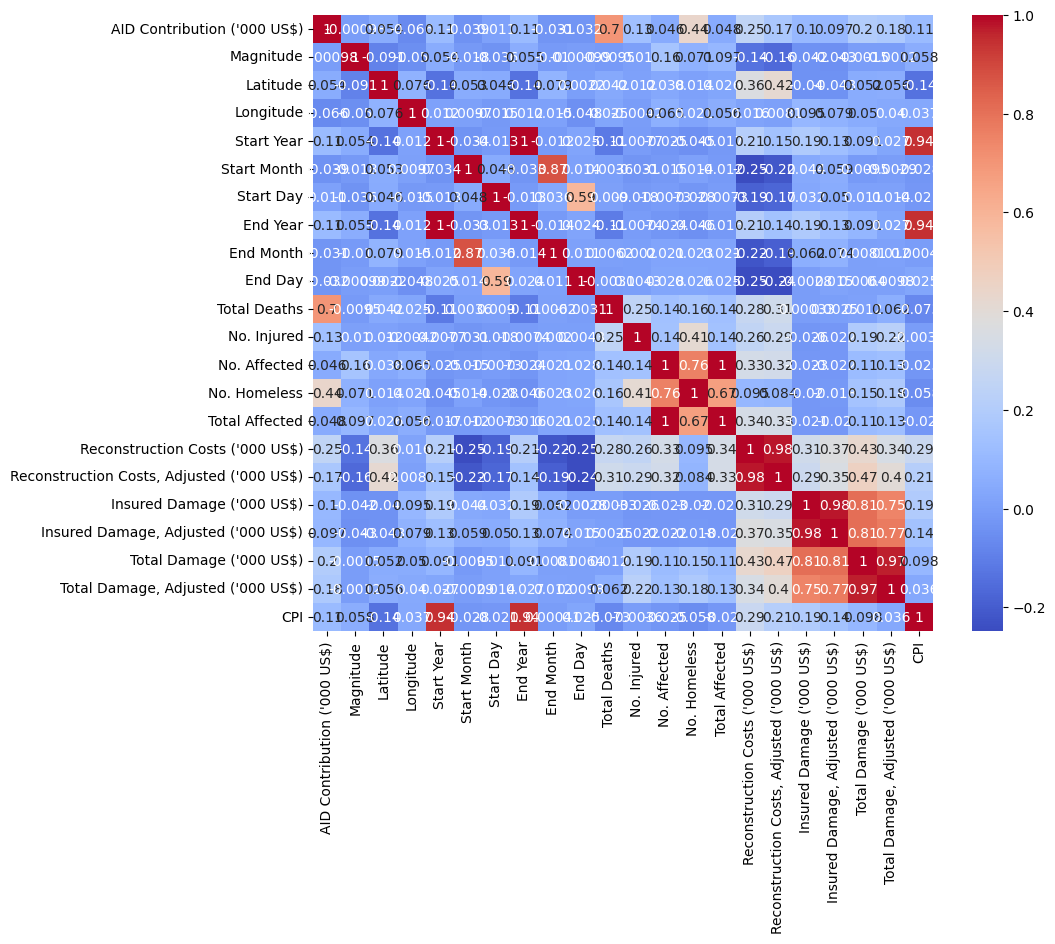

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [72]:
drop_cols = [
    # Leakage - human impact / label hierarchy
    "Historic", "Disaster Subgroup", "Disaster Group", "Disaster Subtype",
    "External IDs", "Event Name", "Location", "Associated Types",
    "Origin", "Country",
    "Admin Units", "GADM Admin Units",

    # Leakage - economic damage (post-event)
    
    "Reconstruction Costs, Adjusted ('000 US$)",
    "Insured Damage, Adjusted ('000 US$)",
    "Total Damage, Adjusted ('000 US$)",

    # Post-event response
    "AID Contribution ('000 US$)", "Appeal", "OFDA/BHA Response","Declaration",
    "No. Injured", "No. Affected", "No. Homeless", "Total Affected",

    # Redundant / unnecessary
    "Classification Key", "ISO",
     "River Basin", "Last Update", 
    "CPI",

    # Many missing values
    "Latitude", "Longitude",

    # Optional
    "Entry Date"
]

data = data.drop(columns=drop_cols, errors='ignore')

In [73]:
print(data.columns)

Index(['Disaster Type', 'Subregion', 'Region', 'Magnitude', 'Magnitude Scale',
       'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month',
       'End Day', 'Total Deaths', 'Reconstruction Costs ('000 US$)',
       'Insured Damage ('000 US$)', 'Total Damage ('000 US$)'],
      dtype='object')


In [74]:
data.shape

(17756, 15)

In [75]:
data.columns = data.columns.str.lower().str.replace(" ", "_")

In [76]:
data.columns

Index(['disaster_type', 'subregion', 'region', 'magnitude', 'magnitude_scale',
       'start_year', 'start_month', 'start_day', 'end_year', 'end_month',
       'end_day', 'total_deaths', 'reconstruction_costs_('000_us$)',
       'insured_damage_('000_us$)', 'total_damage_('000_us$)'],
      dtype='object')

In [77]:
data["start_month"] = data["start_month"].fillna(1)
data["start_day"] = data["start_day"].fillna(1)

data["end_month"] = data["end_month"].fillna(1)
data["end_day"] = data["end_day"].fillna(1)

In [78]:
start_date = pd.to_datetime({
    "year": data["start_year"],
    "month": data["start_month"],
    "day": data["start_day"]
}, errors="coerce")

end_date = pd.to_datetime({
    "year": data["end_year"],
    "month": data["end_month"],
    "day": data["end_day"]
}, errors="coerce")

In [79]:
data["event_duration"] = (end_date - start_date).dt.days

In [80]:
# fix negative duration
data["event_duration"] = data["event_duration"].clip(lower=0)

In [81]:
 #fix missing duration
data["event_duration"] = data["event_duration"].fillna(0)

In [82]:
data = data.drop(columns=[
    "start_year", "start_day",
    "end_year", "end_month", "end_day"
])

In [83]:
data["event_duration"].describe()

count    17756.000000
mean        23.650991
std        113.282786
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max       3287.000000
Name: event_duration, dtype: float64

#Highly right-skewed distribution

In [84]:
data["event_duration_log"] = np.log1p(data["event_duration"])

In [85]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data["event_duration_log_norm"] = scaler.fit_transform(
    data[["event_duration_log"]]
)

In [86]:
data["event_duration_log_norm"].describe()

count    17756.000000
mean         0.140841
std          0.195070
min          0.000000
25%          0.000000
50%          0.000000
75%          0.221259
max          1.000000
Name: event_duration_log_norm, dtype: float64

In [87]:
data.columns

Index(['disaster_type', 'subregion', 'region', 'magnitude', 'magnitude_scale',
       'start_month', 'total_deaths', 'reconstruction_costs_('000_us$)',
       'insured_damage_('000_us$)', 'total_damage_('000_us$)',
       'event_duration', 'event_duration_log', 'event_duration_log_norm'],
      dtype='object')

In [88]:
data.shape

(17756, 13)

In [89]:
numeric_df = data.select_dtypes(include=['number'])
numeric_df

,magnitude,start_month,total_deaths,reconstruction_costs_('000_us$),insured_damage_('000_us$),total_damage_('000_us$),event_duration,event_duration_log,event_duration_log_norm
0,220.0,9.0,6000.0,NaN,NaN,30000.0,0,0.000000,0.000000
1,NaN,1.0,300.0,NaN,NaN,NaN,0,0.000000,0.000000
2,NaN,1.0,30.0,NaN,NaN,NaN,0,0.000000,0.000000
3,NaN,7.0,30.0,NaN,NaN,NaN,0,0.000000,0.000000
4,5.9,7.0,140.0,NaN,NaN,NaN,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
17751,4.9,1.0,1.0,NaN,NaN,483.0,0,0.000000,0.000000
17752,120.0,1.0,3.0,NaN,NaN,NaN,0,0.000000,0.000000
17753,NaN,8.0,115.0,NaN,NaN,NaN,519,6.253829,0.772265
17754,NaN,1.0,21.0,NaN,NaN,NaN,366,5.905362,0.729234


In [90]:
cat_df = data.select_dtypes(include=['object'])
cat_df

,disaster_type,subregion,region,magnitude_scale
0,Storm,Northern America,Americas,Kph
1,Flood,Latin America and the Caribbean,Americas,Km2
2,Epidemic,Latin America and the Caribbean,Americas,Vaccinated
3,Volcanic activity,Eastern Asia,Asia,NaN
4,Earthquake,Western Asia,Asia,Moment Magnitude
...,...,...,...,...
17751,Earthquake,Eastern Asia,Asia,Moment Magnitude
17752,Storm,Southern Asia,Asia,Kph
17753,Drought,Sub-Saharan Africa,Africa,Km2
17754,Drought,Sub-Saharan Africa,Africa,Km2


In [91]:
disaster_merge = {
    "Glacial lake outburst flood": "Flood",

    "Mass movement (dry)": "Landslide",
    "Mass movement (wet)": "Landslide",

    "Infestation": "Epidemic",
    "Animal incident": "Epidemic",

    "Impact": "Earthquake",

    "Fog": "Extreme temperature"
}

data["disaster_type"] = data["disaster_type"].replace(disaster_merge)

In [92]:
data["disaster_type"].value_counts()

disaster_type
Flood                  6183
Storm                  5053
Earthquake             1651
Epidemic               1622
Landslide               918
Drought                 803
Extreme temperature     730
Wildfire                514
Volcanic activity       282
Name: count, dtype: int64

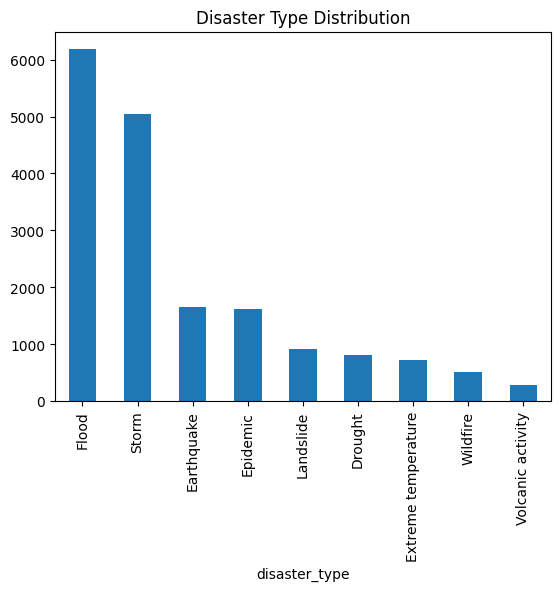

In [93]:
import matplotlib.pyplot as plt

data["disaster_type"].value_counts().plot(kind="bar")
plt.title("Disaster Type Distribution")
plt.show()

In [94]:
data = data[data["disaster_type"] != "Volcanic activity"]

In [95]:
print(data["disaster_type"].value_counts())

disaster_type
Flood                  6183
Storm                  5053
Earthquake             1651
Epidemic               1622
Landslide               918
Drought                 803
Extreme temperature     730
Wildfire                514
Name: count, dtype: int64


In [96]:
print(data.isnull().sum())

disaster_type                          0
subregion                              0
region                                 0
magnitude                          12186
magnitude_scale                     1821
start_month                            0
total_deaths                        4794
reconstruction_costs_('000_us$)    17433
insured_damage_('000_us$)          16327
total_damage_('000_us$)            11805
event_duration                         0
event_duration_log                     0
event_duration_log_norm                0
dtype: int64


In [97]:
drop_cols =[ "event_duration",                         
"event_duration_log"]
data = data.drop(columns=drop_cols, errors='ignore')

In [98]:
data.shape

(17474, 11)

In [99]:
print(data.isnull().sum())

disaster_type                          0
subregion                              0
region                                 0
magnitude                          12186
magnitude_scale                     1821
start_month                            0
total_deaths                        4794
reconstruction_costs_('000_us$)    17433
insured_damage_('000_us$)          16327
total_damage_('000_us$)            11805
event_duration_log_norm                0
dtype: int64


In [100]:
drop_cols =[ "reconstruction_costs_('000_us$)",                         
"insured_damage_('000_us$)"]
data = data.drop(columns=drop_cols, errors='ignore')

In [101]:
print(data.isnull().sum())

disaster_type                  0
subregion                      0
region                         0
magnitude                  12186
magnitude_scale             1821
start_month                    0
total_deaths                4794
total_damage_('000_us$)    11805
event_duration_log_norm        0
dtype: int64


Binary Flagging: Creating a new column to indicate the data was missing which can help the model learn if the missingness itself is informative.

In [102]:
# Create missing indicator
data["magnitude_missing"] = data["magnitude"].isna().astype(int)

In [103]:
# fill missing values with 0
data["magnitude"] = data["magnitude"].fillna(0)

In [104]:
print(data.isnull().sum())

disaster_type                  0
subregion                      0
region                         0
magnitude                      0
magnitude_scale             1821
start_month                    0
total_deaths                4794
total_damage_('000_us$)    11805
event_duration_log_norm        0
magnitude_missing              0
dtype: int64


In [105]:

# FILL MISSING MAGNITUDE_SCALE VALUES
# Based on disaster_type (as we discussed)

data.loc[data['disaster_type'] == 'Earthquake', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Earthquake', 'magnitude_scale'].fillna('Moment Magnitude')

data.loc[data['disaster_type'] == 'Storm', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Storm', 'magnitude_scale'].fillna('Kph')

data.loc[data['disaster_type'] == 'Flood', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Flood', 'magnitude_scale'].fillna('Km2')

data.loc[data['disaster_type'] == 'Extreme temperature', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Extreme temperature', 'magnitude_scale'].fillna('°C')

data.loc[data['disaster_type'] == 'Epidemic', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Epidemic', 'magnitude_scale'].fillna('Morbidity rate')

data.loc[data['disaster_type'] == 'Landslide', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Landslide', 'magnitude_scale'].fillna('Km2')

data.loc[data['disaster_type'] == 'Drought', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Drought', 'magnitude_scale'].fillna('Km2')

data.loc[data['disaster_type'] == 'Wildfire', 'magnitude_scale'] = \
    data.loc[data['disaster_type'] == 'Wildfire', 'magnitude_scale'].fillna('Km2')

# Verify no missing values remain
print(f"Missing in magnitude_scale: {data['magnitude_scale'].isna().sum()}")  # Should be 0

Missing in magnitude_scale: 0


In [106]:
print(data.isnull().sum())

disaster_type                  0
subregion                      0
region                         0
magnitude                      0
magnitude_scale                0
start_month                    0
total_deaths                4794
total_damage_('000_us$)    11805
event_duration_log_norm        0
magnitude_missing              0
dtype: int64


In [107]:
data["total_deaths"] = data["total_deaths"].fillna(0)
data["total_damage_('000_us$)"] = data["total_damage_('000_us$)"].fillna(0)

In [108]:
data.columns

Index(['disaster_type', 'subregion', 'region', 'magnitude', 'magnitude_scale',
       'start_month', 'total_deaths', 'total_damage_('000_us$)',
       'event_duration_log_norm', 'magnitude_missing'],
      dtype='object')

In [109]:
X = data.drop("disaster_type", axis=1)
y = data["disaster_type"]

data = pd.get_dummies(data, columns=["subregion", "region", "magnitude_scale"],  dtype=int)

In [110]:
# Normalizing as features (perfectly fine!)
from sklearn.preprocessing import StandardScaler

# Log Transformation
data["total_deaths_log"] = np.log1p(data["total_deaths"])
data["total_damage_log"] = np.log1p(data["total_damage_('000_us$)"])

# Normalize Total Deaths for use as a feature
scaler = StandardScaler()

data['total_deaths_normalized'] = scaler.fit_transform(data[['total_deaths_log']])

# Normalize Total Damage for use as a feature  
data['total_damage_normalized'] = scaler.fit_transform(data[["total_damage_log"]])

In [111]:
data['total_deaths_normalized'].describe()

count    1.747400e+04
mean     1.951817e-17
std      1.000029e+00
min     -1.101366e+00
25%     -1.101366e+00
50%     -5.501749e-02
75%      6.182029e-01
max      6.100818e+00
Name: total_deaths_normalized, dtype: float64

In [112]:
print(data["magnitude"].dtype)

float64


In [113]:
print(data["magnitude"].describe())
print((data["magnitude"] < 0).sum())

count    1.747400e+04
mean     1.109598e+04
std      1.283309e+05
min     -5.700000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      6.300000e+00
max      1.302587e+07
Name: magnitude, dtype: float64
132


In [114]:
data["magnitude"] = data["magnitude"].clip(lower=0)

In [115]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Step 1: log transform
data["magnitude_log"] = np.log1p(data["magnitude"])

# Step 2: scale
scaler = StandardScaler()
data["magnitude_scaled"] = scaler.fit_transform(data[["magnitude_log"]])

In [116]:
print(data.isnull().sum())

disaster_type                                0
magnitude                                    0
start_month                                  0
total_deaths                                 0
total_damage_('000_us$)                      0
event_duration_log_norm                      0
magnitude_missing                            0
subregion_Australia and New Zealand          0
subregion_Central Asia                       0
subregion_Eastern Asia                       0
subregion_Eastern Europe                     0
subregion_Latin America and the Caribbean    0
subregion_Melanesia                          0
subregion_Micronesia                         0
subregion_Northern Africa                    0
subregion_Northern America                   0
subregion_Northern Europe                    0
subregion_Polynesia                          0
subregion_South-eastern Asia                 0
subregion_Southern Asia                      0
subregion_Southern Europe                    0
subregion_Sub

In [117]:
data['magnitude_scaled'].describe()

count    1.747400e+04
mean     1.138560e-16
std      1.000029e+00
min     -5.205972e-01
25%     -5.205972e-01
50%     -5.205972e-01
75%      9.525251e-02
max      4.554736e+00
Name: magnitude_scaled, dtype: float64

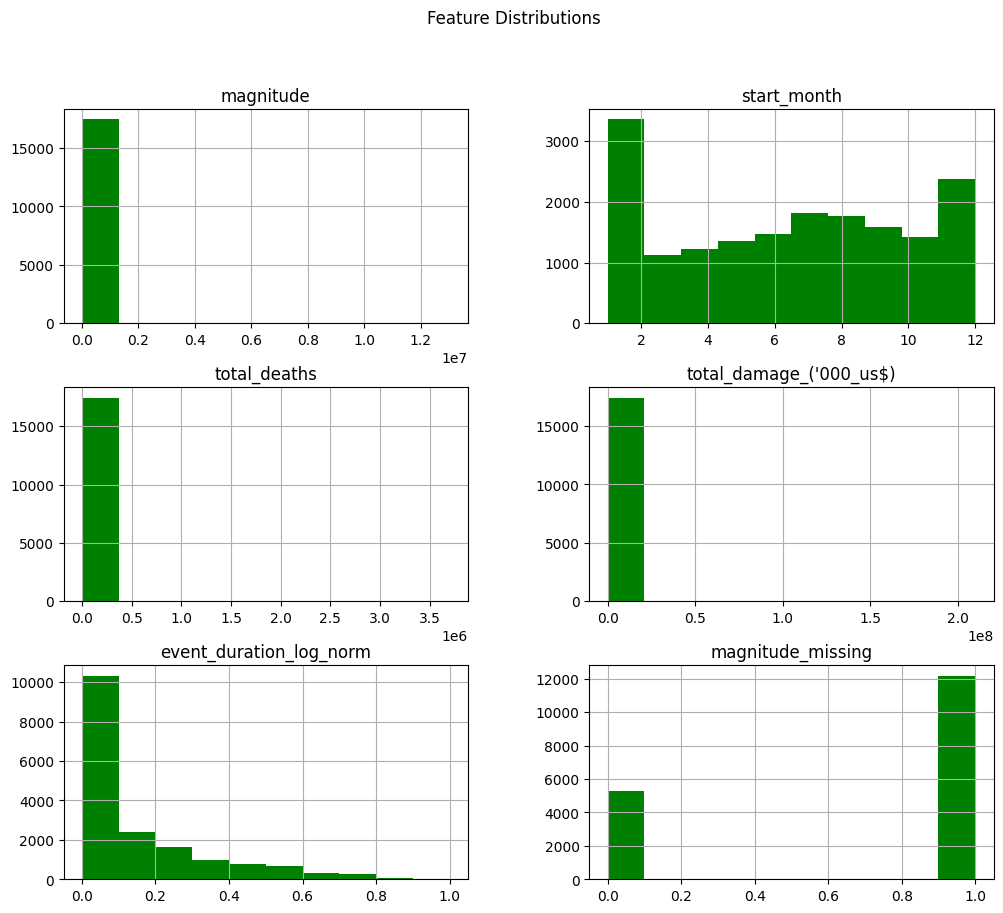

In [118]:
import matplotlib.pyplot as plt

X.hist(figsize=(12,10), color="green")
plt.suptitle("Feature Distributions")
plt.show()

In [119]:
data.columns



Index(['disaster_type', 'magnitude', 'start_month', 'total_deaths',
       'total_damage_('000_us$)', 'event_duration_log_norm',
       'magnitude_missing', 'subregion_Australia and New Zealand',
       'subregion_Central Asia', 'subregion_Eastern Asia',
       'subregion_Eastern Europe', 'subregion_Latin America and the Caribbean',
       'subregion_Melanesia', 'subregion_Micronesia',
       'subregion_Northern Africa', 'subregion_Northern America',
       'subregion_Northern Europe', 'subregion_Polynesia',
       'subregion_South-eastern Asia', 'subregion_Southern Asia',
       'subregion_Southern Europe', 'subregion_Sub-Saharan Africa',
       'subregion_Western Asia', 'subregion_Western Europe', 'region_Africa',
       'region_Americas', 'region_Asia', 'region_Europe', 'region_Oceania',
       'magnitude_scale_Km2', 'magnitude_scale_Kph',
       'magnitude_scale_Moment Magnitude', 'magnitude_scale_Morbidity rate',
       'magnitude_scale_Vaccinated', 'magnitude_scale_°C', 'total_de

In [120]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["disaster_type_encoded"] = pd.Series(le.fit_transform(data["disaster_type"]), index=data.index)

In [121]:
X = data.drop(["disaster_type_encoded", "disaster_type"], axis=1)
y = data["disaster_type_encoded"]

In [122]:
drop_cols = ["total_deaths", "disaster_type","total_damage_('000_us$)", "start_month", "magnitude", "magnitude_log", "total_deaths_log", "total_damage_log"]
data = data.drop(columns=drop_cols, errors='ignore')

In [123]:
data.shape

(17474, 34)

In [124]:
data.to_excel("../data/processed/cleaned_disaster_dataset.xlsx", index=False)